## 1. Data pair distribution

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [59]:
def extract_strains(HI_DataFrame):
    serum_strains = HI_DataFrame[['serumName', 'serumHA', 'serumNA']].drop_duplicates()
    serum_strains.columns = ['Name', 'HA', 'NA']
    serum_strains['Type'] = 'serum'

    virus_strains = HI_DataFrame[['virusName', 'virusHA', 'virusNA']].drop_duplicates()
    virus_strains.columns = ['Name', 'HA', 'NA']
    virus_strains['Type'] = 'virus'

    all_strains = pd.concat([serum_strains, virus_strains]).reset_index(drop=True)
    return all_strains

def generate_onehot_array(strains, HI_DataFrame):
    strains['key'] = list(zip(strains['Name'], strains['HA'], strains['NA']))
    key_to_idx = {key: idx for idx, key in enumerate(strains['key'])}

    # 提取 HI_DataFrame 中的血清和病毒三元组
    serum_keys = list(zip(HI_DataFrame['serumName'], HI_DataFrame['serumHA'], HI_DataFrame['serumNA']))
    virus_keys = list(zip(HI_DataFrame['virusName'], HI_DataFrame['virusHA'], HI_DataFrame['virusNA']))

    # 批量查询索引
    serum_indices = [key_to_idx.get(k) for k in serum_keys]
    virus_indices = [key_to_idx.get(k) for k in virus_keys]

    # 过滤有效索引对并填充矩阵
    valid_pairs = [(s, v) for s, v in zip(serum_indices, virus_indices) if s is not None and v is not None]
    serum_valid, virus_valid = zip(*valid_pairs) if valid_pairs else ([], [])

    # 使用NumPy的向量化操作填充矩阵
    sample_matrix = np.zeros((len(strains), len(strains)))
    sample_matrix[virus_valid,serum_valid] = 1

    count = np.sum(sample_matrix == 1)  # 或 (array == 1).sum()
    print(count)

    sample_matrix = sample_matrix[:, ~np.all(sample_matrix == 0, axis=0)]
    return sample_matrix

def plt_distribution(distribution_array):
    cmap = plt.cm.colors.ListedColormap(['#F5F5F5', 'red'])
    plt.figure(figsize=(6, 3))

    # 显示图像，保持像素比例
    plt.imshow(distribution_array, cmap=cmap, aspect='auto')

    # 添加标题和轴标签
    plt.xlabel('Reference viruses', fontsize=12)
    plt.ylabel('Test viruses', fontsize=12)

    # 调整刻度
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # 获取当前的坐标轴
    ax = plt.gca()

    # 反转 Y 轴
    ax.invert_yaxis()

    # 隐藏坐标轴的边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)


    # 调整布局，确保没有多余边框
    plt.tight_layout()

    # 显示图像
    plt.show()

In [ ]:
Crick_H1N1 = pd.read_excel('../../data/raw/data4model(Crick-H1N1).xlsx')
Crick_H3N2 = pd.read_excel('../../data/raw/data4model(Crick-H3N2).xlsx')

H1N1_strains = extract_strains(Crick_H1N1)[['Name', 'HA', 'NA']]
H3N2_strains = extract_strains(Crick_H3N2)[['Name', 'HA', 'NA']]
print(len(H1N1_strains))
print(len(H3N2_strains))

6225
5628


In [53]:
H1N1_array = generate_onehot_array(H1N1_strains, Crick_H1N1)
H3N2_array = generate_onehot_array(H3N2_strains, Crick_H3N2)

55411
48148


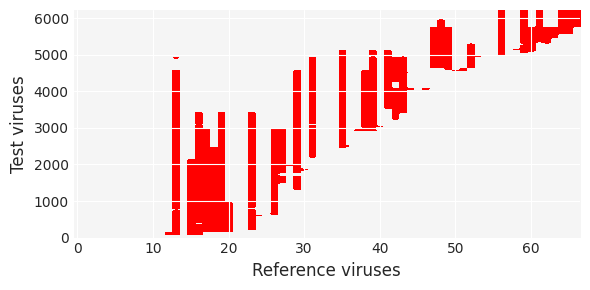

In [60]:
plt_distribution(H1N1_array)

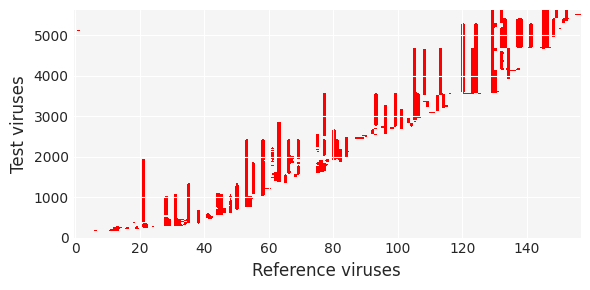

In [61]:
plt_distribution(H3N2_array)

## 2. Virus distribution